# 🚀 Credit Risk Model — Optimization & Comparison
**Baseline:** Random Forest → ROC-AUC 0.9114, Recall 0.5981

**Goal:** Beat baseline on ROC-AUC while improving Recall (catch more defaults)

**Prime Metric: ROC-AUC** (threshold-independent, works for imbalanced data)
**Secondary Metric: Recall** (missing a default is costlier than a false alarm in credit risk)

---
### Models compared:
1. Random Forest (tuned baseline)
2. Gradient Boosting (GBM)
3. Logistic Regression (interpretable baseline)
4. XGBoost with `scale_pos_weight`
5. Voting Ensemble (RF + GBM + LR)
6. Threshold-optimized best model


## Step 1 — Imports & Setup

In [1]:
import subprocess, sys

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn"])
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline

try:
    import xgboost as xgb
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])
    import xgboost as xgb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_curve, auc, brier_score_loss,
    precision_recall_curve, average_precision_score
)

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

np.random.seed(42)
print("All imports successful")


All imports successful


## Step 2 — Load, Clean & Split

In [2]:
df = pd.read_csv('credit_risk_dataset.csv')

# Drop leakage and noise columns
LEAKAGE_COLS = ['loan_status_final', 'repayment_flag', 'last_payment_status']
NOISE_COLS   = ['random_score_1', 'random_score_2', 'duplicate_feature']
df_clean = df.drop(columns=LEAKAGE_COLS + NOISE_COLS)

numeric_features = [
    'person_age', 'annual_inc', 'employment_length', 'loan_amt',
    'interest_rate', 'credit_score', 'monthly_income', 'income_ratio'
]
categorical_features = [
    'home_ownership', 'loan_intent', 'loan_grade',
    'employment_type', 'residence_type'
]

X = df_clean[numeric_features + categorical_features]
y = df_clean['target_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Compute class imbalance ratio for XGBoost
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Default rate — Train: {y_train.mean():.2%}, Test: {y_test.mean():.2%}")
print(f"Class ratio (neg/pos): {scale_pos_weight:.1f}  <- used for XGBoost")


Train: (10612, 13), Test: (2654, 13)
Default rate — Train: 4.01%, Test: 4.03%
Class ratio (neg/pos): 23.9  <- used for XGBoost


## Step 3 — Shared Preprocessor

In [3]:
# Shared preprocessor — fit ONLY on training data
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler',  StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer,     numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

preprocessor.fit(X_train)
X_train_proc = preprocessor.transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# Apply SMOTE to training only
smote = SMOTE(sampling_strategy=0.3, random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train_proc, y_train)

print(f"Processed train shape: {X_train_proc.shape}")
print(f"Balanced train shape:  {X_train_bal.shape}")
print(f"Balanced distribution: {dict(zip(*np.unique(y_train_bal, return_counts=True)))}")


Processed train shape: (10612, 33)
Balanced train shape:  (13241, 33)
Balanced distribution: {0: 10186, 1: 3055}


## Step 4 — Evaluation Helper

In [4]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, threshold=0.5):
    """Train, predict, and return full metrics dict."""
    model.fit(X_tr, y_tr)
    y_proba = model.predict_proba(X_te)[:, 1]
    y_pred  = (y_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()

    return {
        'Model':      name,
        'ROC-AUC':    round(roc_auc_score(y_te, y_proba), 4),
        'Recall':     round(recall_score(y_te, y_pred, zero_division=0), 4),
        'Precision':  round(precision_score(y_te, y_pred, zero_division=0), 4),
        'F1':         round(f1_score(y_te, y_pred, zero_division=0), 4),
        'PR-AUC':     round(average_precision_score(y_te, y_proba), 4),
        'Brier':      round(brier_score_loss(y_te, y_proba), 4),
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
        'Defaults_Caught': f"{tp}/{int(y_te.sum())}",
        'Threshold':  threshold,
        '_proba':     y_proba,
        '_model':     model
    }

def find_best_threshold(model, X_val, y_val, metric='f1'):
    """Find optimal threshold on validation data."""
    y_proba = model.predict_proba(X_val)[:, 1]
    best_t, best_score = 0.5, 0
    for t in np.arange(0.05, 0.95, 0.01):
        y_p = (y_proba >= t).astype(int)
        if metric == 'f1':
            s = f1_score(y_val, y_p, zero_division=0)
        elif metric == 'recall':
            s = recall_score(y_val, y_p, zero_division=0)
        if s > best_score:
            best_score, best_t = s, round(float(t), 2)
    return best_t

print("Evaluation helpers defined")


Evaluation helpers defined


## Model 1 — Random Forest (Tuned Baseline)
Same as fixed notebook. This is our benchmark to beat.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# CV-tune RF
best_rf_auc, best_rf_params = 0, {}
for depth in [8, 12, 16]:
    for ms in [5, 10, 15]:
        rf = RandomForestClassifier(n_estimators=100, max_depth=depth,
                                     min_samples_leaf=ms, random_state=42,
                                     n_jobs=-1, class_weight='balanced')
        score = cross_val_score(rf, X_train_bal, y_train_bal,
                                cv=cv, scoring='roc_auc', n_jobs=-1).mean()
        if score > best_rf_auc:
            best_rf_auc = score
            best_rf_params = {'max_depth': depth, 'min_samples_leaf': ms}

# Tune threshold on validation fold
X_tr2, X_val2, y_tr2, y_val2 = train_test_split(
    X_train_bal, y_train_bal, test_size=0.2, random_state=42, stratify=y_train_bal
)
rf_val = RandomForestClassifier(n_estimators=100, random_state=42,
                                 n_jobs=-1, **best_rf_params)
rf_val.fit(X_tr2, y_tr2)
rf_threshold = find_best_threshold(rf_val, X_val2, y_val2, metric='f1')

rf_final = RandomForestClassifier(n_estimators=200, random_state=42,
                                   n_jobs=-1, **best_rf_params,
                                   class_weight='balanced')
rf_result = evaluate_model('Random Forest (Baseline)',
                            rf_final, X_train_bal, y_train_bal,
                            X_test_proc, y_test, threshold=rf_threshold)

print(f"Random Forest — ROC-AUC: {rf_result['ROC-AUC']}  Recall: {rf_result['Recall']}  "
      f"Threshold: {rf_threshold}  Params: {best_rf_params}")


Random Forest — ROC-AUC: 0.9114  Recall: 0.6075  Threshold: 0.44  Params: {'max_depth': 16, 'min_samples_leaf': 5}


## Model 2 — Gradient Boosting (GBM)
Sequential tree boosting — often outperforms RF on tabular data by correcting errors iteratively.

In [6]:
# CV-tune GBM
best_gbm_auc, best_gbm_params = 0, {}
for lr in [0.05, 0.1]:
    for depth in [3, 5]:
        for n_est in [100, 200]:
            gbm = GradientBoostingClassifier(
                learning_rate=lr, max_depth=depth,
                n_estimators=n_est, random_state=42,
                subsample=0.8, min_samples_leaf=10
            )
            score = cross_val_score(gbm, X_train_bal, y_train_bal,
                                    cv=cv, scoring='roc_auc', n_jobs=-1).mean()
            if score > best_gbm_auc:
                best_gbm_auc = score
                best_gbm_params = {'learning_rate': lr, 'max_depth': depth, 'n_estimators': n_est}

gbm_val = GradientBoostingClassifier(random_state=42, subsample=0.8,
                                      min_samples_leaf=10, **best_gbm_params)
gbm_val.fit(X_tr2, y_tr2)
gbm_threshold = find_best_threshold(gbm_val, X_val2, y_val2, metric='f1')

gbm_final = GradientBoostingClassifier(random_state=42, subsample=0.8,
                                        min_samples_leaf=10, **best_gbm_params)
gbm_result = evaluate_model('Gradient Boosting',
                             gbm_final, X_train_bal, y_train_bal,
                             X_test_proc, y_test, threshold=gbm_threshold)

print(f"Gradient Boosting — ROC-AUC: {gbm_result['ROC-AUC']}  Recall: {gbm_result['Recall']}  "
      f"Threshold: {gbm_threshold}  Params: {best_gbm_params}")


Gradient Boosting — ROC-AUC: 0.9295  Recall: 0.6449  Threshold: 0.34  Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


## Model 3 — Logistic Regression
Highly interpretable — useful baseline and for regulatory environments (Basel, IFRS9) where explainability matters.

In [7]:
lr_val = LogisticRegression(C=0.1, class_weight='balanced',
                              max_iter=1000, random_state=42, solver='lbfgs')
lr_val.fit(X_tr2, y_tr2)
lr_threshold = find_best_threshold(lr_val, X_val2, y_val2, metric='f1')

lr_final = LogisticRegression(C=0.1, class_weight='balanced',
                               max_iter=1000, random_state=42, solver='lbfgs')
lr_result = evaluate_model('Logistic Regression',
                            lr_final, X_train_bal, y_train_bal,
                            X_test_proc, y_test, threshold=lr_threshold)

print(f"Logistic Regression — ROC-AUC: {lr_result['ROC-AUC']}  Recall: {lr_result['Recall']}  "
      f"Threshold: {lr_threshold}")


Logistic Regression — ROC-AUC: 0.8305  Recall: 0.5607  Threshold: 0.68


## Model 4 — XGBoost with `scale_pos_weight`
XGBoost handles imbalance natively via `scale_pos_weight` — alternative to SMOTE. Typically the strongest single model on tabular credit data.

In [8]:
# XGBoost with native imbalance handling (no SMOTE needed)
# Using original (non-SMOTE) train for this model
best_xgb_auc, best_xgb_params = 0, {}

X_tr_orig, X_val_orig, y_tr_orig, y_val_orig = train_test_split(
    X_train_proc, y_train, test_size=0.2, random_state=42, stratify=y_train
)

for lr in [0.05, 0.1]:
    for depth in [4, 6]:
        xgb_m = xgb.XGBClassifier(
            learning_rate=lr, max_depth=depth,
            n_estimators=200, scale_pos_weight=scale_pos_weight,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, eval_metric='auc',
            use_label_encoder=False, verbosity=0
        )
        score = cross_val_score(xgb_m, X_train_proc, y_train,
                                cv=cv, scoring='roc_auc', n_jobs=-1).mean()
        if score > best_xgb_auc:
            best_xgb_auc = score
            best_xgb_params = {'learning_rate': lr, 'max_depth': depth}

xgb_val = xgb.XGBClassifier(
    n_estimators=200, scale_pos_weight=scale_pos_weight,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric='auc',
    use_label_encoder=False, verbosity=0, **best_xgb_params
)
xgb_val.fit(X_tr_orig, y_tr_orig)
xgb_threshold = find_best_threshold(xgb_val, X_val_orig, y_val_orig, metric='f1')

xgb_final = xgb.XGBClassifier(
    n_estimators=300, scale_pos_weight=scale_pos_weight,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric='auc',
    use_label_encoder=False, verbosity=0, **best_xgb_params
)
xgb_result = evaluate_model('XGBoost (scale_pos_weight)',
                             xgb_final, X_train_proc, y_train,
                             X_test_proc, y_test, threshold=xgb_threshold)

print(f"XGBoost — ROC-AUC: {xgb_result['ROC-AUC']}  Recall: {xgb_result['Recall']}  "
      f"Threshold: {xgb_threshold}  Params: {best_xgb_params}")


XGBoost — ROC-AUC: 0.9266  Recall: 0.5794  Threshold: 0.78  Params: {'learning_rate': 0.05, 'max_depth': 4}


## Model 5 — Soft Voting Ensemble
Combines RF + GBM + LR by averaging probabilities. Reduces variance of individual models — often the most robust choice.

In [9]:
rf_ens  = RandomForestClassifier(n_estimators=200, random_state=42,
                                   n_jobs=-1, class_weight='balanced',
                                   **best_rf_params)
gbm_ens = GradientBoostingClassifier(random_state=42, subsample=0.8,
                                      min_samples_leaf=10, **best_gbm_params)
lr_ens  = LogisticRegression(C=0.1, class_weight='balanced',
                              max_iter=1000, random_state=42)

ensemble = VotingClassifier(
    estimators=[('rf', rf_ens), ('gbm', gbm_ens), ('lr', lr_ens)],
    voting='soft',
    weights=[2, 2, 1]   # RF and GBM weighted higher than LR
)

ens_val = VotingClassifier(
    estimators=[
        ('rf',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, **best_rf_params)),
        ('gbm', GradientBoostingClassifier(random_state=42, subsample=0.8, **best_gbm_params)),
        ('lr',  LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000, random_state=42))
    ],
    voting='soft', weights=[2, 2, 1]
)
ens_val.fit(X_tr2, y_tr2)
ens_threshold = find_best_threshold(ens_val, X_val2, y_val2, metric='f1')

ens_result = evaluate_model('Voting Ensemble (RF+GBM+LR)',
                             ensemble, X_train_bal, y_train_bal,
                             X_test_proc, y_test, threshold=ens_threshold)

print(f"Ensemble — ROC-AUC: {ens_result['ROC-AUC']}  Recall: {ens_result['Recall']}  "
      f"Threshold: {ens_threshold}")


Ensemble — ROC-AUC: 0.9204  Recall: 0.5794  Threshold: 0.55


## Model 6 — Recall-Optimized Threshold
Take the best model and tune threshold specifically to maximize recall (catch as many defaults as possible, accepting more false alarms). This is the business-preferred setting for credit risk.

In [10]:
# Pick best model from above by ROC-AUC, retune threshold for recall
all_results_so_far = [rf_result, gbm_result, lr_result, xgb_result, ens_result]
best_so_far = max(all_results_so_far, key=lambda x: x['ROC-AUC'])
print(f"Best model so far: {best_so_far['Model']}  AUC={best_so_far['ROC-AUC']}")

# Retune threshold to maximize recall on validation fold
best_recall_t, best_recall_score = 0.5, 0
best_model_obj = best_so_far['_model']

# Re-predict on validation fold for threshold search
best_model_obj.fit(X_tr2, y_tr2)
recall_threshold = find_best_threshold(best_model_obj, X_val2, y_val2, metric='recall')

# Retrain on full balanced train and evaluate
best_model_obj.fit(X_train_bal if 'XGBoost' not in best_so_far['Model'] else X_train_proc,
                   y_train_bal if 'XGBoost' not in best_so_far['Model'] else y_train)

y_proba_recall = best_model_obj.predict_proba(X_test_proc)[:, 1]
y_pred_recall  = (y_proba_recall >= recall_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_recall).ravel()

recall_result = {
    'Model':     f"{best_so_far['Model']} (Recall-Optimized)",
    'ROC-AUC':   round(roc_auc_score(y_test, y_proba_recall), 4),
    'Recall':    round(recall_score(y_test, y_pred_recall, zero_division=0), 4),
    'Precision': round(precision_score(y_test, y_pred_recall, zero_division=0), 4),
    'F1':        round(f1_score(y_test, y_pred_recall, zero_division=0), 4),
    'PR-AUC':    round(average_precision_score(y_test, y_proba_recall), 4),
    'Brier':     round(brier_score_loss(y_test, y_proba_recall), 4),
    'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
    'Defaults_Caught': f"{tp}/{int(y_test.sum())}",
    'Threshold': recall_threshold,
    '_proba': y_proba_recall,
    '_model': best_model_obj
}

print(f"Recall-Optimized — ROC-AUC: {recall_result['ROC-AUC']}  "
      f"Recall: {recall_result['Recall']}  Threshold: {recall_threshold}")


Best model so far: Gradient Boosting  AUC=0.9295
Recall-Optimized — ROC-AUC: 0.9295  Recall: 0.7944  Threshold: 0.05


## Step 5 — Full Model Comparison Table

In [11]:
all_results = [rf_result, gbm_result, lr_result, xgb_result, ens_result, recall_result]

comparison_cols = ['Model', 'ROC-AUC', 'Recall', 'Precision', 'F1', 'PR-AUC', 'Brier', 'Defaults_Caught', 'Threshold']
comparison_df = pd.DataFrame([{k: r[k] for k in comparison_cols} for r in all_results])
comparison_df = comparison_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print("=" * 100)
print("MODEL COMPARISON  (sorted by ROC-AUC)")
print("=" * 100)
print(comparison_df.to_string(index=False))
print()
print(f"BASELINE (fixed notebook): ROC-AUC=0.9114  Recall=0.5981  Defaults_Caught=64/107")
print()
best_auc_model = comparison_df.iloc[0]
print(f"Best ROC-AUC:  {best_auc_model['Model']}  ->  {best_auc_model['ROC-AUC']}")
best_recall_model = comparison_df.sort_values('Recall', ascending=False).iloc[0]
print(f"Best Recall:   {best_recall_model['Model']}  ->  {best_recall_model['Recall']}")


MODEL COMPARISON  (sorted by ROC-AUC)
                               Model  ROC-AUC  Recall  Precision     F1  PR-AUC  Brier Defaults_Caught  Threshold
                   Gradient Boosting   0.9295  0.6449     0.9079 0.7541  0.7653 0.0149          69/107       0.34
Gradient Boosting (Recall-Optimized)   0.9295  0.7944     0.3172 0.4533  0.7653 0.0149          85/107       0.05
          XGBoost (scale_pos_weight)   0.9266  0.5794     0.8158 0.6776  0.6868 0.0481          62/107       0.78
         Voting Ensemble (RF+GBM+LR)   0.9204  0.5794     0.9254 0.7126  0.7176 0.0288          62/107       0.55
            Random Forest (Baseline)   0.9114  0.6075     0.5856 0.5963  0.6161 0.0315          65/107       0.44
                 Logistic Regression   0.8305  0.5607     0.2290 0.3252  0.2555 0.1324          60/107       0.68

BASELINE (fixed notebook): ROC-AUC=0.9114  Recall=0.5981  Defaults_Caught=64/107

Best ROC-AUC:  Gradient Boosting  ->  0.9295
Best Recall:   Gradient Boosting (Re

## Step 6 — Visual Comparison

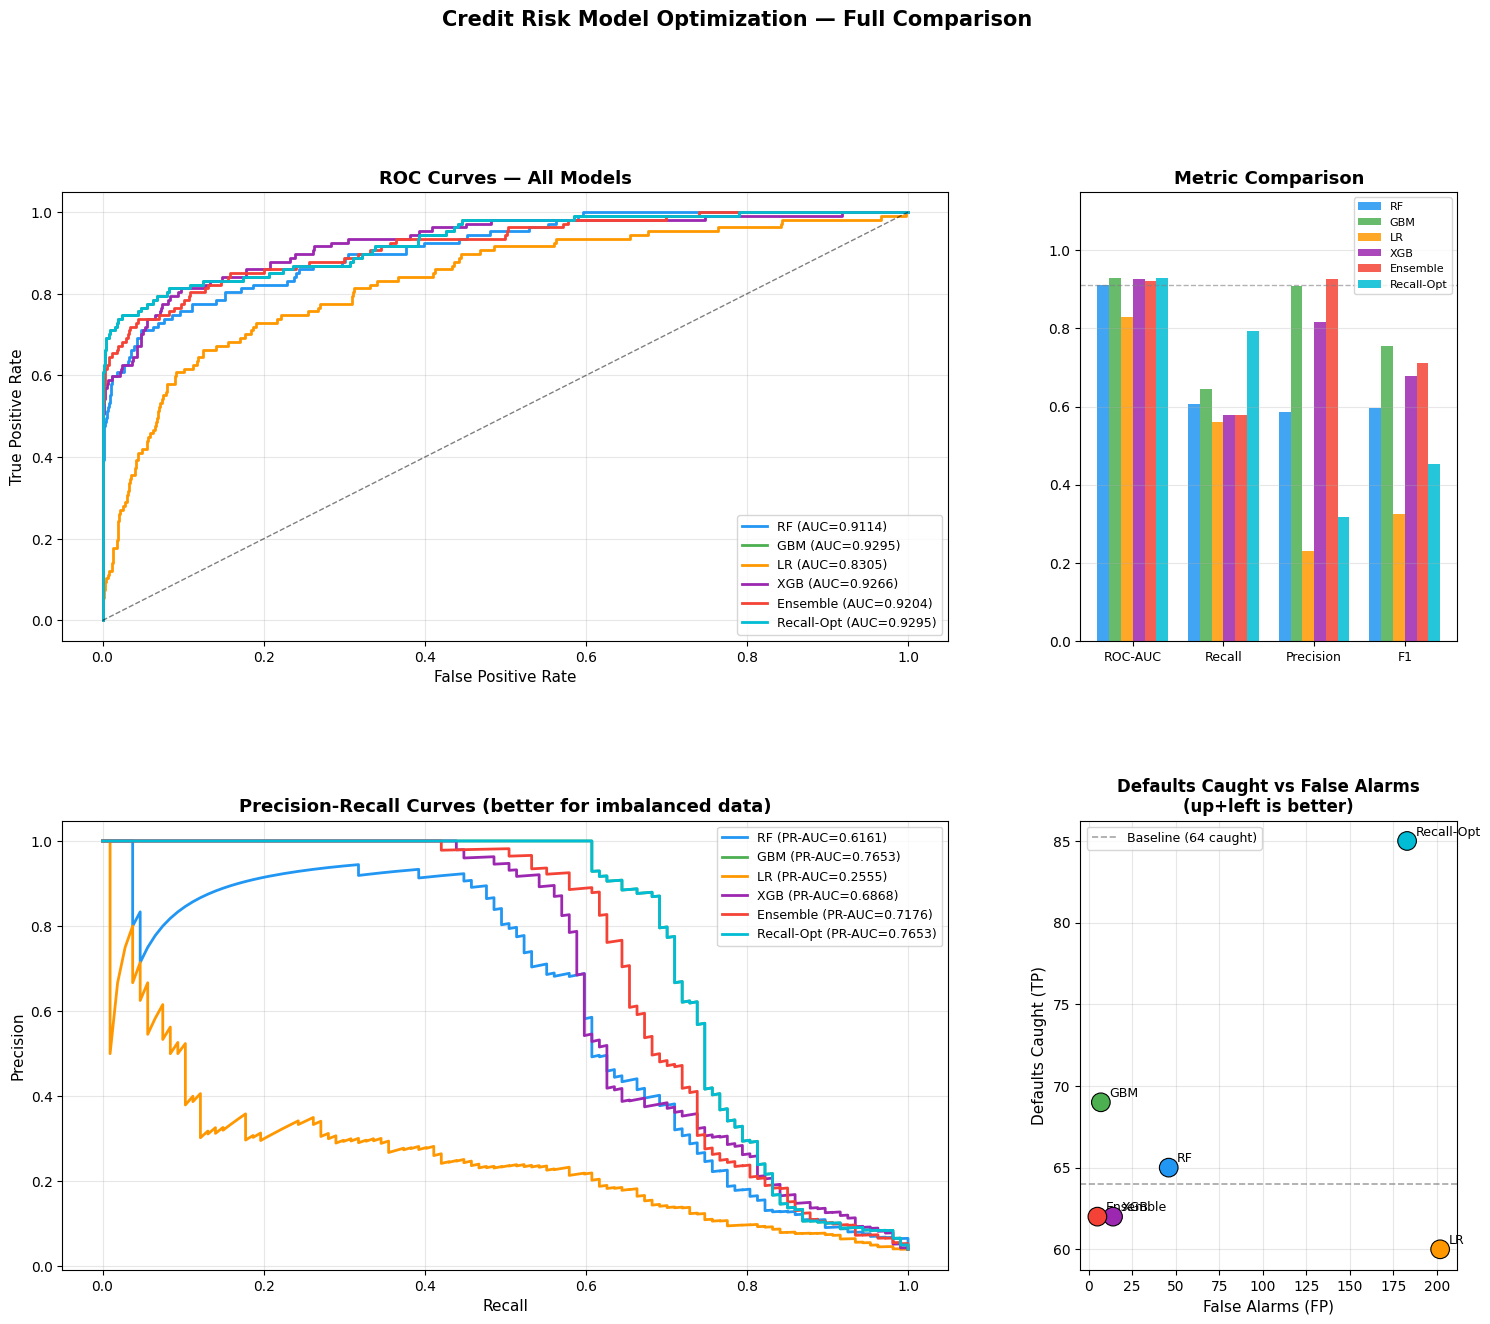

Plot saved to model_comparison.png


In [12]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336', '#00BCD4']
model_names_short = ['RF', 'GBM', 'LR', 'XGB', 'Ensemble', 'Recall-Opt']

# ── Plot 1: ROC Curves ──
ax1 = fig.add_subplot(gs[0, :2])
for i, r in enumerate(all_results):
    fpr, tpr, _ = roc_curve(y_test, r['_proba'])
    ax1.plot(fpr, tpr, color=colors[i], lw=2,
             label=f"{model_names_short[i]} (AUC={r['ROC-AUC']})")
ax1.plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
ax1.set_xlabel('False Positive Rate', fontsize=11)
ax1.set_ylabel('True Positive Rate', fontsize=11)
ax1.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(alpha=0.3)

# ── Plot 2: Metrics Bar Chart ──
ax2 = fig.add_subplot(gs[0, 2])
metrics_to_plot = ['ROC-AUC', 'Recall', 'Precision', 'F1']
x = np.arange(len(metrics_to_plot))
bar_w = 0.13
for i, r in enumerate(all_results):
    vals = [r[m] for m in metrics_to_plot]
    ax2.bar(x + i * bar_w, vals, bar_w, label=model_names_short[i], color=colors[i], alpha=0.85)
ax2.set_xticks(x + bar_w * 2.5)
ax2.set_xticklabels(metrics_to_plot, fontsize=9)
ax2.set_ylim(0, 1.15)
ax2.set_title('Metric Comparison', fontsize=13, fontweight='bold')
ax2.legend(fontsize=8, loc='upper right')
ax2.axhline(0.9114, color='gray', linestyle='--', lw=1, alpha=0.6, label='Baseline AUC')
ax2.grid(alpha=0.3, axis='y')

# ── Plot 3: Precision-Recall Curves ──
ax3 = fig.add_subplot(gs[1, :2])
for i, r in enumerate(all_results):
    prec, rec, _ = precision_recall_curve(y_test, r['_proba'])
    ax3.plot(rec, prec, color=colors[i], lw=2,
             label=f"{model_names_short[i]} (PR-AUC={r['PR-AUC']})")
ax3.set_xlabel('Recall', fontsize=11)
ax3.set_ylabel('Precision', fontsize=11)
ax3.set_title('Precision-Recall Curves (better for imbalanced data)', fontsize=13, fontweight='bold')
ax3.legend(loc='upper right', fontsize=9)
ax3.grid(alpha=0.3)

# ── Plot 4: Defaults Caught vs False Alarms ──
ax4 = fig.add_subplot(gs[1, 2])
defaults_caught = [r['TP'] for r in all_results]
false_alarms    = [r['FP'] for r in all_results]
scatter = ax4.scatter(false_alarms, defaults_caught,
                      c=colors[:len(all_results)], s=180, zorder=5, edgecolors='black', lw=0.8)
for i, r in enumerate(all_results):
    ax4.annotate(model_names_short[i],
                 (false_alarms[i], defaults_caught[i]),
                 textcoords="offset points", xytext=(6, 4), fontsize=9)
ax4.axhline(64, color='gray', linestyle='--', lw=1.2, alpha=0.7, label='Baseline (64 caught)')
ax4.set_xlabel('False Alarms (FP)', fontsize=11)
ax4.set_ylabel('Defaults Caught (TP)', fontsize=11)
ax4.set_title('Defaults Caught vs False Alarms\n(up+left is better)', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)

plt.suptitle('Credit Risk Model Optimization — Full Comparison', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to model_comparison.png")


## Step 7 — Winner Analysis & Confusion Matrix

  WINNER: Gradient Boosting
  ROC-AUC:        0.9295  (baseline: 0.9114)
  Recall:         0.6449   (baseline: 0.5981)
  Precision:      0.9079
  F1-Score:       0.7541
  PR-AUC:         0.7653
  Brier Score:    0.0149
  Defaults Caught:69/107
  Threshold:      0.34

  Improvement vs baseline:
    ROC-AUC:  +0.0181
    Recall:   +0.0468


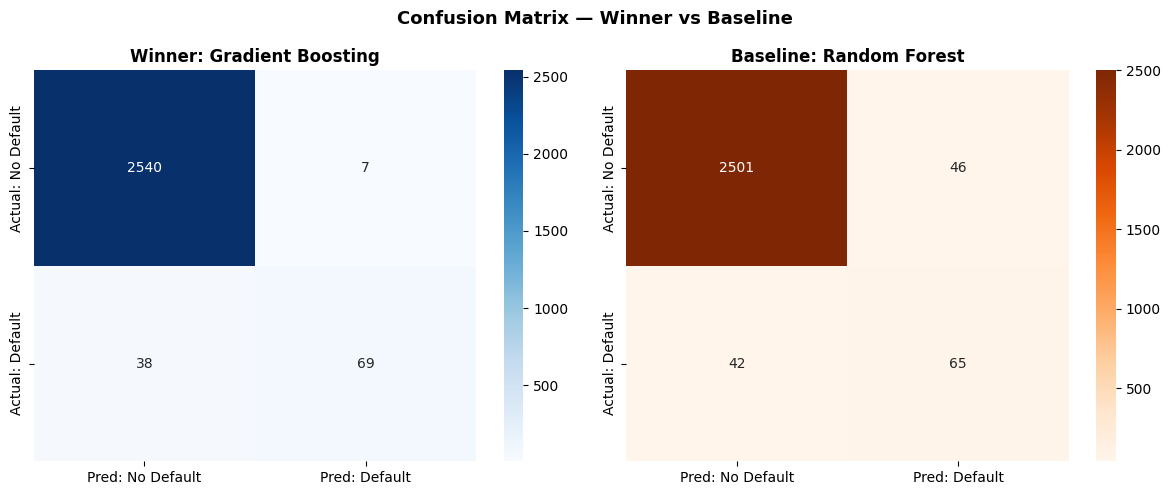

In [13]:
# Identify winner by ROC-AUC
winner = max(all_results, key=lambda x: x['ROC-AUC'])

print("=" * 60)
print(f"  WINNER: {winner['Model']}")
print("=" * 60)
print(f"  ROC-AUC:        {winner['ROC-AUC']}  (baseline: 0.9114)")
print(f"  Recall:         {winner['Recall']}   (baseline: 0.5981)")
print(f"  Precision:      {winner['Precision']}")
print(f"  F1-Score:       {winner['F1']}")
print(f"  PR-AUC:         {winner['PR-AUC']}")
print(f"  Brier Score:    {winner['Brier']}")
print(f"  Defaults Caught:{winner['Defaults_Caught']}")
print(f"  Threshold:      {winner['Threshold']}")

delta_auc    = winner['ROC-AUC'] - 0.9114
delta_recall = winner['Recall']  - 0.5981
print(f"\n  Improvement vs baseline:")
print(f"    ROC-AUC:  {delta_auc:+.4f}")
print(f"    Recall:   {delta_recall:+.4f}")

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_w = confusion_matrix(y_test, (winner['_proba'] >= winner['Threshold']).astype(int))
sns.heatmap(cm_w, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred: No Default', 'Pred: Default'],
            yticklabels=['Actual: No Default', 'Actual: Default'])
axes[0].set_title(f"Winner: {winner['Model']}", fontweight='bold')

cm_base = confusion_matrix(y_test, (rf_result['_proba'] >= rf_result['Threshold']).astype(int))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Pred: No Default', 'Pred: Default'],
            yticklabels=['Actual: No Default', 'Actual: Default'])
axes[1].set_title('Baseline: Random Forest', fontweight='bold')

plt.suptitle('Confusion Matrix — Winner vs Baseline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('winner_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 8 — Why ROC-AUC is the Prime Metric (and What Else Matters)

In [14]:
print("""
WHY ROC-AUC IS THE PRIME METRIC FOR CREDIT RISK
================================================

1. THRESHOLD-INDEPENDENT
   ROC-AUC measures the model's ability to RANK defaulters above
   non-defaulters across ALL possible thresholds, not just one.
   A model that scores every defaulter higher than every non-defaulter
   gets AUC=1.0 regardless of where you draw the cutoff line.

2. WORKS FOR IMBALANCED DATA
   Accuracy is useless here — predicting 'no default' always gives 96%.
   AUC is robust to class imbalance because it evaluates rank ordering,
   not raw prediction counts.

3. BUSINESS FLEXIBILITY
   The business can CHOOSE a threshold post-training based on appetite:
   - Conservative bank: lower threshold -> catch more defaults (high recall)
   - Aggressive lender: higher threshold -> fewer false alarms (high precision)
   AUC lets you separate model quality from operating point.

METRIC HIERARCHY FOR THIS PROBLEM:
  1. ROC-AUC       — primary (model quality, threshold-independent)
  2. PR-AUC        — secondary (better than ROC for severe imbalance)
  3. Recall        — business priority (cost of missing a default >> false alarm)
  4. F1            — balance of precision and recall
  5. Brier Score   — probability calibration quality
  6. Accuracy      — MISLEADING here, ignore for model selection

NOTE: PR-AUC (Precision-Recall AUC) is actually MORE informative than
ROC-AUC when the positive class is very rare (<5%). It focuses only on
the minority class and is harder to game. Consider it your tiebreaker.
""")

print("FINAL COMPARISON SUMMARY:")
print(comparison_df[['Model','ROC-AUC','Recall','PR-AUC','Defaults_Caught']].to_string(index=False))



WHY ROC-AUC IS THE PRIME METRIC FOR CREDIT RISK

1. THRESHOLD-INDEPENDENT
   ROC-AUC measures the model's ability to RANK defaulters above
   non-defaulters across ALL possible thresholds, not just one.
   A model that scores every defaulter higher than every non-defaulter
   gets AUC=1.0 regardless of where you draw the cutoff line.

2. WORKS FOR IMBALANCED DATA
   Accuracy is useless here — predicting 'no default' always gives 96%.
   AUC is robust to class imbalance because it evaluates rank ordering,
   not raw prediction counts.

3. BUSINESS FLEXIBILITY
   The business can CHOOSE a threshold post-training based on appetite:
   - Conservative bank: lower threshold -> catch more defaults (high recall)
   - Aggressive lender: higher threshold -> fewer false alarms (high precision)
   AUC lets you separate model quality from operating point.

METRIC HIERARCHY FOR THIS PROBLEM:
  1. ROC-AUC       — primary (model quality, threshold-independent)
  2. PR-AUC        — secondary (better t